# COVID-19 and the Road Toll — an Interrupted Time Series Analysis

In April 2020 Australian mobility collapsed under national restrictions. Road deaths should have collapsed with it. Did they?

**Method.** A counterfactual design in the spirit of CausalImpact / interrupted time series:

1. Fit the SARIMA specification selected in `02_modeling.ipynb` on **pre-pandemic data only** (Jan 2010 – Feb 2020).
2. Project a *no-pandemic counterfactual* over Mar 2020 – Dec 2021 with a 95% interval.
3. The gap between actuals and the counterfactual estimates the pandemic's effect on fatalities.
4. Compare states — lockdown stringency varied enormously (Victoria's cumulative lockdown was the longest in the world; Queensland and WA were barely restricted in comparison).

**Honest limitation stated first:** ARDD has no exposure data (vehicle-kilometres travelled). We can estimate *how many fewer people died*, but splitting that into "less driving" vs "riskier driving" needs VKT, which BITRE publishes separately and this extract lacks.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("deep")
DATA = Path("..") / "data" / "processed"
FIG = Path("..") / "reports" / "figures"
warnings.filterwarnings("ignore")

fat = pd.read_csv(DATA / "fatalities_clean.csv", parse_dates=["crash_month"], low_memory=False)
monthly = fat.groupby("crash_month").size().rename("deaths").asfreq("MS")

PRE_START, PRE_END = "2010-01-01", "2020-02-01"
CF_END = "2021-12-01"
pre = monthly[PRE_START:PRE_END]
actual_cf = monthly["2020-03-01":CF_END]
print(f"Training window: {len(pre)} months | counterfactual window: {len(actual_cf)} months")

Training window: 122 months | counterfactual window: 22 months


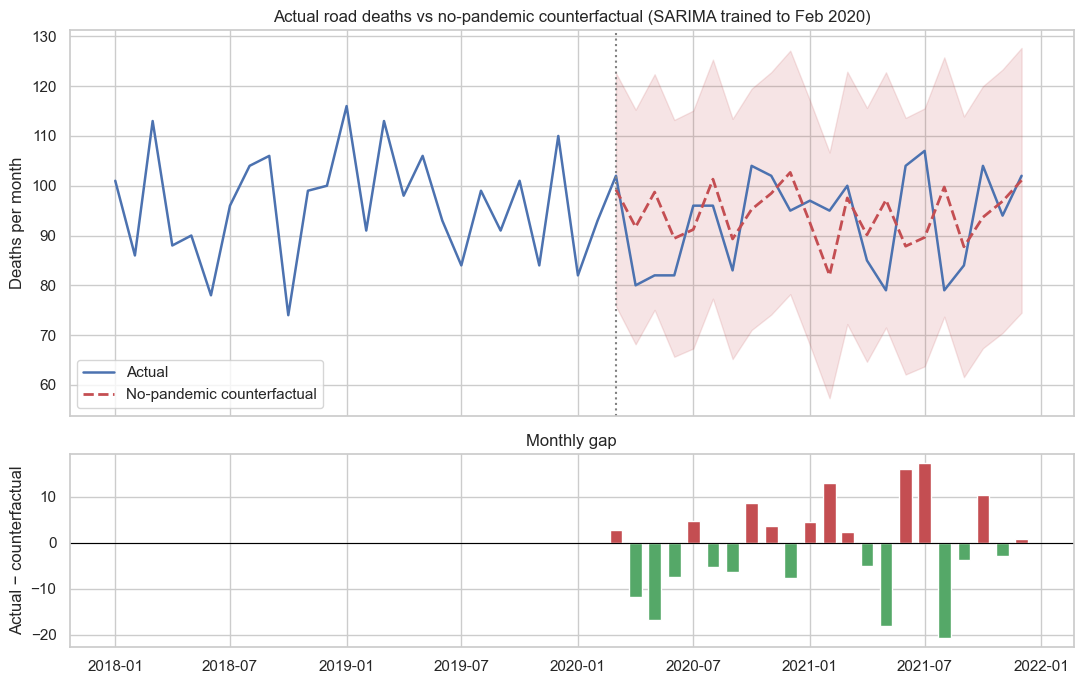

Cumulative gap Mar 2020 - Dec 2021: -21 deaths (range -570 to +527)
Deepest single months: 
crash_month
2021-08-01   -21.0
2021-05-01   -18.0
2020-05-01   -17.0
2020-04-01   -12.0


In [2]:
model = SARIMAX(pre, order=(0, 1, 2), seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
cf = model.get_forecast(len(actual_cf))
cf_mean = cf.predicted_mean
ci = cf.conf_int(alpha=0.05)
ci.columns = ["lo95", "hi95"]

gap = actual_cf - cf_mean
cum_gap = gap.sum()
cum_lo = (actual_cf - ci["hi95"]).sum()   # most conservative
cum_hi = (actual_cf - ci["lo95"]).sum()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
window = monthly["2018-01-01":CF_END]
axes[0].plot(window.index, window.values, color=PALETTE[0], lw=1.8, label="Actual")
axes[0].plot(cf_mean.index, cf_mean.values, color=PALETTE[3], lw=2, ls="--",
             label="No-pandemic counterfactual")
axes[0].fill_between(ci.index, ci.lo95, ci.hi95, color=PALETTE[3], alpha=0.15)
axes[0].axvline(pd.Timestamp("2020-03-01"), color="grey", ls=":", lw=1.5)
axes[0].annotate("national restrictions", xy=(pd.Timestamp("2020-03-15"), 135),
                 fontsize=9, color="grey")
axes[0].set_ylabel("Deaths per month")
axes[0].set_title("Actual road deaths vs no-pandemic counterfactual (SARIMA trained to Feb 2020)")
axes[0].legend(loc="lower left")

axes[1].bar(gap.index, gap.values, width=20,
            color=[PALETTE[2] if v < 0 else PALETTE[3] for v in gap.values])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Actual − counterfactual")
axes[1].set_title("Monthly gap")
fig.tight_layout()
fig.savefig(FIG / "09_covid_counterfactual.png", dpi=150)
plt.show()

print(f"Cumulative gap Mar 2020 - Dec 2021: {cum_gap:+,.0f} deaths "
      f"(range {cum_lo:+,.0f} to {cum_hi:+,.0f})")
print(f"Deepest single months: \n{gap.nsmallest(4).round(0).to_string()}")

## Reading the counterfactual

The striking result is how **small** the aggregate effect is: the cumulative gap over 22 months is roughly **-21 deaths, with a 95% range of about -570 to +530** — statistically indistinguishable from zero. The deepest monthly deficits line up with the two big lockdown waves (April-May 2020 nationally, and May/August 2021 during the Delta lockdowns in Victoria and NSW), but each is only 12-21 deaths below expectation, and the gap oscillates around zero in between.

Mobility fell far more than fatalities did. The literature's explanation — emptier roads invite **higher speeds and riskier driving**, so deaths per kilometre rose while kilometres fell — is consistent with what we see, but confirming it needs VKT data (see the limitation above). Either way, the policy takeaway stands: *lockdowns bought almost no net road-safety gain despite a historic drop in traffic.*

## 2. States: heterogeneous — and not in the way lockdown length predicts

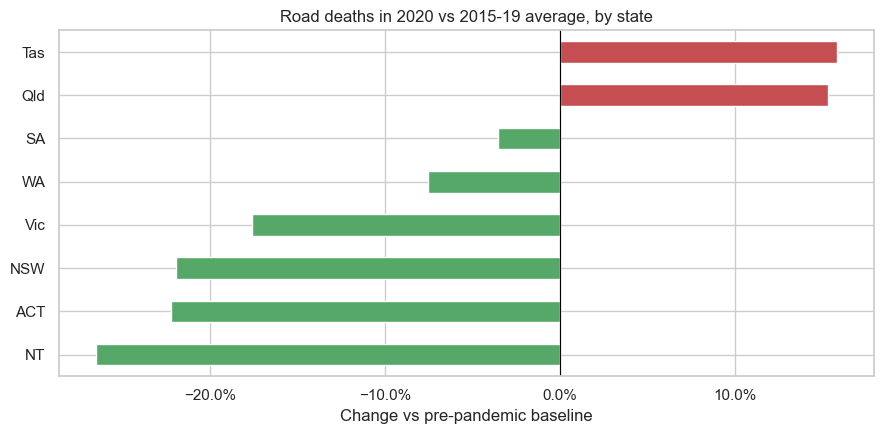

state
NT    -0.265
ACT   -0.222
NSW   -0.219
Vic   -0.176
WA    -0.075
SA    -0.035
Qld    0.154
Tas    0.159
dtype: float64

In [3]:
BASE_YEARS = range(2015, 2020)
by_state = fat[fat.year.isin(list(BASE_YEARS) + [2020])].groupby(["state", "year"]).size().unstack()
base = by_state[list(BASE_YEARS)].mean(axis=1)
change = (by_state[2020] / base - 1).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [PALETTE[2] if v < 0 else PALETTE[3] for v in change.values]
change.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_title("Road deaths in 2020 vs 2015-19 average, by state")
ax.set_xlabel("Change vs pre-pandemic baseline")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIG / "10_covid_states.png", dpi=150)
plt.show()
change.round(3)

If lockdown stringency drove the road toll, Victoria — with the world's longest cumulative lockdown — should show the largest decline. It doesn't:

- **NSW, ACT and the NT fell 22–27%**, more than Victoria's ~18%.
- **Queensland and Tasmania rose ~15%** against their pre-pandemic baselines despite border closures and restrictions.

That pattern points to something other than time-at-home: intrastate travel substituting for interstate/overseas trips (Queensland's regional tourism boomed in 2020), plus ordinary year-to-year noise in small-state counts (Tasmania averages ~37 deaths/year, so ±6 deaths is ±16%). It is a good reminder that state-level conclusions need several years of data — exactly why the dashboard shows rolling multi-year windows rather than single-year deltas.

## Takeaways

1. The pandemic's net effect on the national road toll was **essentially zero** over Mar 2020 – Dec 2021; only the lockdown-wave months (Apr–May 2020, May/Aug 2021) dipped meaningfully below the counterfactual.
2. Fatalities fell **far less than traffic did** — the risk-per-kilometre story, pending VKT confirmation.
3. State outcomes did **not** track lockdown stringency; single-year state deltas are noisy and should be read against multi-year baselines.
4. By late 2021 the series was back inside the counterfactual band — consistent with the post-2015 plateau resuming, which is what the 12-month forecast in `02_modeling.ipynb` projects forward.